
# Hybrid Ontology-Inspired CAD Assembly Similarity Framework

This notebook implements:
- Technical similarity
- Semantic similarity
- Structural similarity
- Hybrid similarity fusion
- Real CAD dataset validation
- Empirical robustness analysis
- Runtime benchmarking
- k-NN classification evaluation
- Graph-based structural modeling
- Visualization export to PDF
- Table export to CSV

Dataset:
Fusion360 Gallery Assembly Dataset (metadata extraction)


In [1]:

# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import time
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)


In [2]:

# ============================================================
# CELL 2 — LOAD DATASET
# ============================================================

df = pd.read_csv("real_assembly_dataset.csv")

print(df.head())

df.to_csv("tables/raw_dataset_preview.csv", index=False)


  assembly_name  component_count  joint_count  body_count        mass  \
0      Untitled                9            0          13    0.744615   
1      Untitled                1            0           3  329.950068   
2      Untitled               14            0          20    7.856136   
3      Untitled                3            1           2    0.673383   
4      Untitled                3            2           3    2.914357   

         volume  edge_count  face_count     material  
0     94.855453         577         256  Steel, Mild  
1  42031.855829          52          24  Steel, Mild  
2   1004.986442        3156        1263  Steel, Mild  
3     85.781305          42          18  Steel, Mild  
4    371.255706          68          32  Steel, Mild  


In [3]:

# ============================================================
# CELL 3 — MATERIAL NORMALIZATION
# ============================================================

def simplify_material(mat):

    mat = str(mat).lower()

    if "steel" in mat:
        return "Steel"

    elif "aluminum" in mat:
        return "Aluminum"

    elif "abs" in mat:
        return "Plastic"

    elif "wood" in mat:
        return "Wood"

    else:
        return "Other"

df["material_simple"] = df["material"].apply(
    simplify_material
)

material_summary = df["material_simple"].value_counts()

material_summary.to_csv("tables/material_distribution.csv")


In [4]:

# ============================================================
# CELL 4 — CREATE ENGINEERING CLASSES
# ============================================================

classes = []

for i in range(len(df)):

    mass = df.loc[i, 'mass']
    joints = df.loc[i, 'joint_count']
    components = df.loc[i, 'component_count']

    if mass > 20 and components > 10:
        classes.append(0)

    elif joints > 2:
        classes.append(1)

    else:
        classes.append(2)

df['class'] = classes

labels = df['class'].values

class_distribution = df['class'].value_counts()

class_distribution.to_csv("tables/class_distribution.csv")

print(class_distribution)


class
2    40
1     5
0     3
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 5 — FEATURE EXTRACTION
# ============================================================

technical_features = df[[
    'mass',
    'volume',
    'edge_count',
    'face_count'
]]

semantic_features = pd.get_dummies(
    df[['material_simple']]
)

structural_features = df[[
    'component_count',
    'joint_count',
    'body_count'
]]

# Feature summary table

feature_summary = pd.DataFrame({

    "Feature": [

        'mass',
        'volume',
        'edge_count',
        'face_count',

        'component_count',
        'joint_count',
        'body_count'

    ],

    "Category": [

        'Technical',
        'Technical',
        'Technical',
        'Technical',

        'Structural',
        'Structural',
        'Structural'
    ]
})

feature_summary.to_csv(
    "tables/feature_summary.csv",
    index=False
)

feature_summary


,Feature,Category
0,mass,Technical
1,volume,Technical
2,edge_count,Technical
3,face_count,Technical
4,component_count,Structural
5,joint_count,Structural
6,body_count,Structural


In [7]:

# ============================================================
# CELL 6 — FEATURE SCALING
# ============================================================

scaler = StandardScaler()

tech_scaled = scaler.fit_transform(
    technical_features
)

struct_scaled = scaler.fit_transform(
    structural_features
)


In [8]:

# ============================================================
# CELL 7 — SIMILARITY MATRICES
# ============================================================

technical_similarity = cosine_similarity(
    tech_scaled
)

semantic_similarity = cosine_similarity(
    semantic_features
)

structural_similarity = cosine_similarity(
    struct_scaled
)


In [9]:

# ============================================================
# CELL 8 — HYBRID SIMILARITY FUSION
# ============================================================

alpha = 0.2
beta = 0.5
gamma = 0.3

hybrid_similarity = (
    alpha * technical_similarity +
    beta * semantic_similarity +
    gamma * structural_similarity
)

weights_table = pd.DataFrame({
    "Weight": ["alpha", "beta", "gamma"],
    "Value": [alpha, beta, gamma]
})

weights_table.to_csv("tables/hybrid_weights.csv", index=False)


In [10]:

# ============================================================
# CELL 9 — PRECISION@K
# ============================================================

def precision_at_k(
    similarity_matrix,
    labels,
    k=5
):

    precisions = []

    for i in range(len(labels)):

        sims = similarity_matrix[i]

        ranked = np.argsort(
            sims
        )[::-1][1:k+1]

        relevant = sum(
            labels[j] == labels[i]
            for j in ranked
        )

        precisions.append(
            relevant / k
        )

    return np.mean(precisions)

tech_score = precision_at_k(
    technical_similarity,
    labels
)

semantic_score = precision_at_k(
    semantic_similarity,
    labels
)

hybrid_score = precision_at_k(
    hybrid_similarity,
    labels
)

results_table = pd.DataFrame({
    "Method": ["Technical", "Semantic", "Hybrid"],
    "Precision@5": [
        tech_score,
        semantic_score,
        hybrid_score
    ]
})

results_table.to_csv(
    "tables/similarity_results.csv",
    index=False
)

print(results_table)


      Method  Precision@5
0  Technical     0.758333
1   Semantic     0.833333
2     Hybrid     0.850000


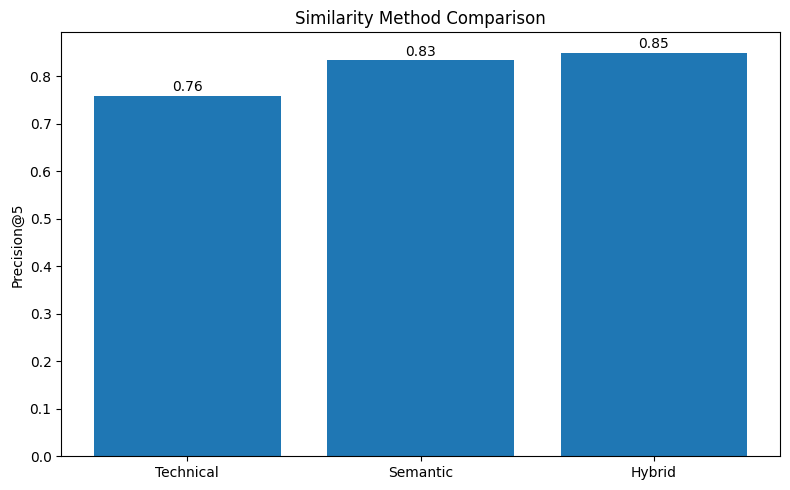

In [11]:

# ============================================================
# CELL 10 — METHOD COMPARISON CHART
# ============================================================

methods = [
    'Technical',
    'Semantic',
    'Hybrid'
]

scores = [
    tech_score,
    semantic_score,
    hybrid_score
]

plt.figure(figsize=(8,5))

plt.bar(methods, scores)

plt.ylabel("Precision@5")

plt.title(
    "Similarity Method Comparison"
)

for i, v in enumerate(scores):

    plt.text(
        i,
        v + 0.01,
        f"{v:.2f}",
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    "figures/method_comparison.pdf"
)

plt.show()


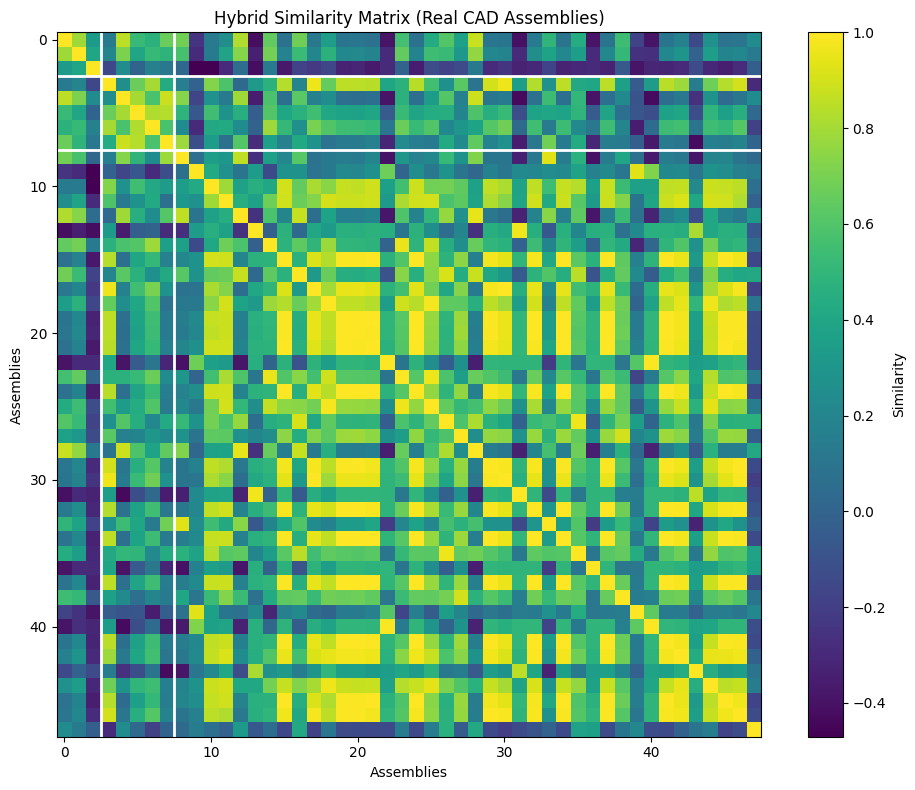

In [12]:

# ============================================================
# CELL 11 — HYBRID HEATMAP
# ============================================================

sorted_indices = np.argsort(labels)

sorted_similarity = hybrid_similarity[
    sorted_indices
][:, sorted_indices]

sorted_labels = labels[sorted_indices]

boundaries = []

for i in range(1, len(sorted_labels)):

    if sorted_labels[i] != sorted_labels[i - 1]:
        boundaries.append(i)

plt.figure(figsize=(10,8))

plt.imshow(sorted_similarity)

for b in boundaries:

    plt.axhline(
        b - 0.5,
        color='white',
        linewidth=2
    )

    plt.axvline(
        b - 0.5,
        color='white',
        linewidth=2
    )

plt.colorbar(label='Similarity')

plt.title(
    "Hybrid Similarity Matrix "
    "(Real CAD Assemblies)"
)

plt.xlabel("Assemblies")
plt.ylabel("Assemblies")

plt.tight_layout()

plt.savefig(
    "figures/hybrid_heatmap.pdf"
)

plt.show()


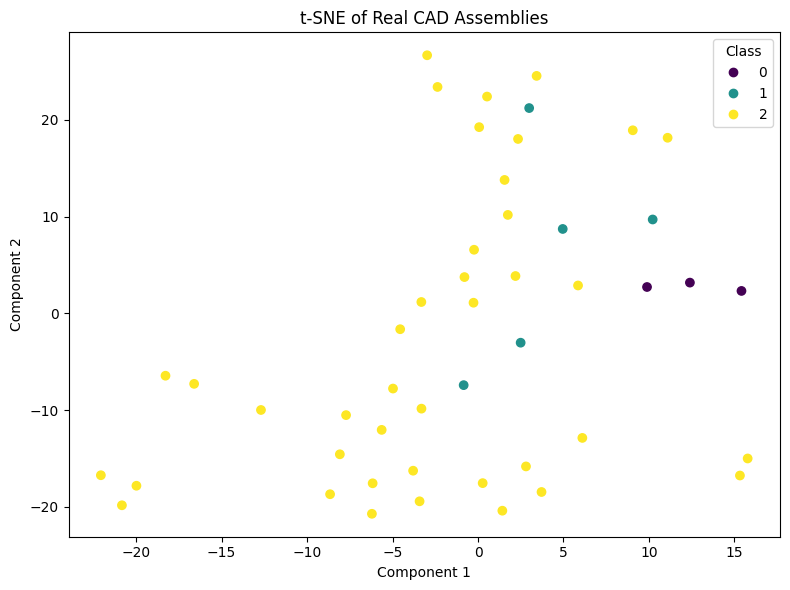

In [13]:

# ============================================================
# CELL 12 — t-SNE VISUALIZATION
# ============================================================

X = np.concatenate([

    tech_scaled,

    semantic_features.values,

    struct_scaled

], axis=1)

embedded = TSNE(

    n_components=2,

    random_state=42,

    perplexity=10

).fit_transform(X)

plt.figure(figsize=(8,6))

scatter = plt.scatter(

    embedded[:,0],

    embedded[:,1],

    c=labels

)

plt.title(
    "t-SNE of Real CAD Assemblies"
)

plt.xlabel("Component 1")

plt.ylabel("Component 2")

plt.legend(
    *scatter.legend_elements(),
    title="Class"
)

plt.tight_layout()

plt.savefig(
    "figures/tsne_embedding.pdf"
)

plt.show()


/var/folders/5g/xvbyr6sj6h9bmtvf5km0m3n80000gn/T/ipykernel_56918/3129718024.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


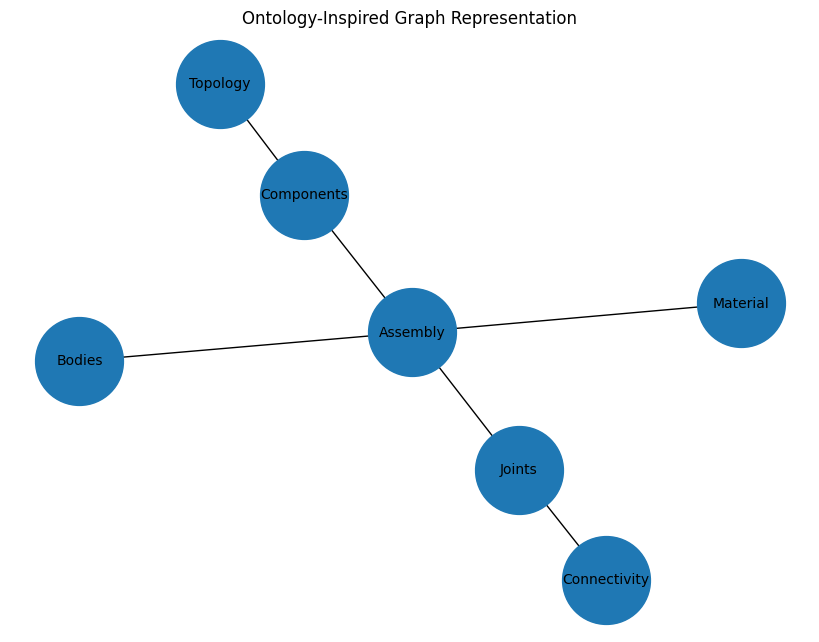

In [14]:

# ============================================================
# CELL 13 — GRAPH REPRESENTATION
# ============================================================

G = nx.Graph()

G.add_node("Assembly")

G.add_edges_from([
    ("Assembly", "Components"),
    ("Assembly", "Joints"),
    ("Assembly", "Bodies"),
    ("Assembly", "Material"),
    ("Components", "Topology"),
    ("Joints", "Connectivity")
])

plt.figure(figsize=(8,6))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=4000,
    font_size=10
)

plt.title(
    "Ontology-Inspired Graph Representation"
)

plt.tight_layout()

plt.savefig(
    "figures/ontology_graph.pdf"
)

plt.show()


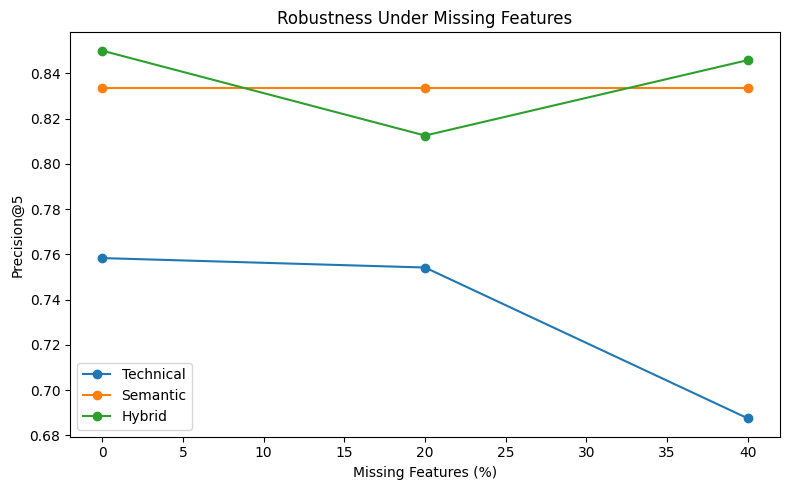

In [15]:

# ============================================================
# CELL 14 — EMPIRICAL ROBUSTNESS ANALYSIS
# ============================================================

def simulate_missing_features(X, missing_percent):

    X_copy = X.copy()

    total = X_copy.size

    missing = int(total * missing_percent)

    idx = np.random.choice(
        total,
        missing,
        replace=False
    )

    flat = X_copy.flatten()

    flat[idx] = 0

    return flat.reshape(X_copy.shape)

missing_levels = [0, 0.2, 0.4]

technical_scores = []
semantic_scores = []
hybrid_scores = []

for m in missing_levels:

    tech_missing = simulate_missing_features(
        tech_scaled,
        m
    )

    struct_missing = simulate_missing_features(
        struct_scaled,
        m
    )

    tech_sim = cosine_similarity(
        tech_missing
    )

    struct_sim = cosine_similarity(
        struct_missing
    )

    hybrid_missing = (
        alpha * tech_sim +
        beta * semantic_similarity +
        gamma * struct_sim
    )

    technical_scores.append(
        precision_at_k(
            tech_sim,
            labels
        )
    )

    semantic_scores.append(
        precision_at_k(
            semantic_similarity,
            labels
        )
    )

    hybrid_scores.append(
        precision_at_k(
            hybrid_missing,
            labels
        )
    )

robustness_table = pd.DataFrame({
    "Missing Features (%)": [
        int(x*100) for x in missing_levels
    ],
    "Technical": technical_scores,
    "Semantic": semantic_scores,
    "Hybrid": hybrid_scores
})

robustness_table.to_csv(
    "tables/robustness_results.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.plot(
    [x*100 for x in missing_levels],
    technical_scores,
    marker='o',
    label='Technical'
)

plt.plot(
    [x*100 for x in missing_levels],
    semantic_scores,
    marker='o',
    label='Semantic'
)

plt.plot(
    [x*100 for x in missing_levels],
    hybrid_scores,
    marker='o',
    label='Hybrid'
)

plt.xlabel("Missing Features (%)")

plt.ylabel("Precision@5")

plt.title(
    "Robustness Under Missing Features"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/robustness_analysis.pdf"
)

plt.show()


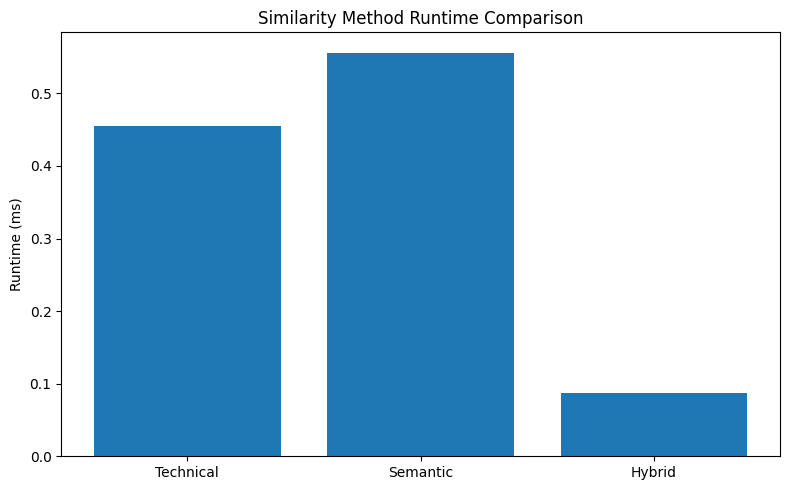

In [16]:

# ============================================================
# CELL 15 — REAL RUNTIME BENCHMARKING
# ============================================================

runtime_results = {}

start = time.time()
cosine_similarity(tech_scaled)
runtime_results["Technical"] = (
    time.time() - start
) * 1000

start = time.time()
cosine_similarity(semantic_features)
runtime_results["Semantic"] = (
    time.time() - start
) * 1000

start = time.time()

_ = (
    alpha * technical_similarity +
    beta * semantic_similarity +
    gamma * structural_similarity
)

runtime_results["Hybrid"] = (
    time.time() - start
) * 1000

runtime_table = pd.DataFrame({
    "Method": list(runtime_results.keys()),
    "Runtime (ms)": list(runtime_results.values())
})

runtime_table.to_csv(
    "tables/runtime_results.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.bar(
    runtime_table["Method"],
    runtime_table["Runtime (ms)"]
)

plt.ylabel("Runtime (ms)")

plt.title(
    "Similarity Method Runtime Comparison"
)

plt.tight_layout()

plt.savefig(
    "figures/runtime_comparison.pdf"
)

plt.show()


In [17]:

# ============================================================
# CELL 16 — k-NN CLASSIFICATION
# ============================================================

X_ml = np.concatenate([
    tech_scaled,
    semantic_features.values,
    struct_scaled
], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    labels,
    test_size=0.3,
    random_state=42
)

knn = KNeighborsClassifier(
    n_neighbors=3
)

knn.fit(X_train, y_train)

preds = knn.predict(X_test)

accuracy = accuracy_score(
    y_test,
    preds
)

report = classification_report(
    y_test,
    preds,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "tables/knn_classification_report.csv"
)

print("k-NN Accuracy:", accuracy)

print(report_df)


k-NN Accuracy: 1.0
              precision  recall  f1-score  support
0                   1.0     1.0       1.0      1.0
1                   1.0     1.0       1.0      1.0
2                   1.0     1.0       1.0     13.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     15.0
weighted avg        1.0     1.0       1.0     15.0


In [18]:

# ============================================================
# CELL 17 — FINAL DATASET SUMMARY
# ============================================================

summary_table = pd.DataFrame({
    "Statistic": [
        "Assemblies",
        "Technical Features",
        "Semantic Features",
        "Structural Features"
    ],
    "Value": [
        len(df),
        len(technical_features.columns),
        len(semantic_features.columns),
        len(structural_features.columns)
    ]
})

summary_table.to_csv(
    "tables/dataset_summary.csv",
    index=False
)

print(summary_table)


             Statistic  Value
0           Assemblies     48
1   Technical Features      4
2    Semantic Features      5
3  Structural Features      3
